# Train/Test Loss Convergence for the Random-Feature Shallow Masked Diffusion Model

We study the shallow masked diffusion model on structured binary data generated by a fixed random-feature matrix $F$.

The numerical goal is to verify that, as the sample load

$$
\alpha = M/D
$$

increases at fixed latent dimension $D$ and fixed visible-to-latent ratio

$$
\gamma = N/D,
$$

the training loss increases from below while the test loss decreases from above, with both converging to the same limiting value.

We also investigate:
1. **Finite-size scaling** by repeating curves for different latent dimensions $D$.
2. **Aspect-ratio scaling** by repeating curves for different visible-to-latent ratios $\gamma = N/D$.


## Notation

We use the professor’s notation:

$$
D = \text{latent dimension},
$$

$$
N = \text{visible dimension / sequence length},
$$

$$
M = \text{number of training samples}.
$$

The two proportional-limit ratios are:

$$
\alpha = \frac{M}{D},
$$

$$
\gamma = \frac{N}{D}.
$$

Note that plain $M$ denotes the number of training samples and should not be confused with the set of masked coordinates at a given time step $t$. We denote the set of masked coordinate indices separately as:

$$
\mathcal M_t = \{i : x_i^t = [m]\}.
$$

For the basic convergence plot, we fix $D$ and $\gamma=N/D$, and sweep the sample load $\alpha=M/D$.

Since $D$ is fixed, sweeping $\alpha$ is equivalent to sweeping $M$.

In the codebase, the visible dimension $N$ is called `L`, so $N=L$.

The codebase parameter `alpha` means

$$
\alpha_{\mathrm{code}}=\frac{M}{N}.
$$

Therefore,

$$
\alpha_{\mathrm{code}}
=
\frac{\alpha}{\gamma}.
$$

For numerical stability and to match the baseline, we evaluate the loss at a fixed masking level. If $K$ denotes the number of visible context coordinates, then

$$
t_{\mathrm{mask}}=1-\frac{K}{N}.
$$

The context size $K$ is not part of the professor’s main notation; it only specifies the masking level used for the numerical diagnostic.


## 3. Imports

We import standard numerical libraries, PyTorch, PyTorch Lightning, and the classes `RandomFeaturesDataset` and `MaskedDiffusion` from our codebase.

In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader

# Robust path logic: add the project root directory containing datasets.py and diffusion.py
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from datasets import RandomFeaturesDataset
from diffusion import MaskedDiffusion


## 4. Fixed Parameters

We specify the fixed parameters for the training sweep. We set $D=20$. We define list parameters for $\gamma$ (`gamma_prof_values`) and $\alpha$ (`alpha_prof_values`) to support nested sweeps. The masking probability $t_{\mathrm{mask}}$ is determined by a fixed context size $K = \text{round}(\kappa \cdot D)$ with $\kappa = 0.5$.


In [ ]:
# Fixed Parameter Setup
D_values = [10, 20, 50, 50]             # latent dimensions to check finite-size effects
gamma_prof_values = [1.0, 2.0]  # professor's gamma = N / D to check aspect-ratio effects
alpha_prof_values = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]  # professor's alpha = M / D (sample load)

# Masking setup (fixed context ratio relative to latent dimension kappa = K/D)
kappa = 0.5
M_test = 1000  # fixed number of test samples
num_steps = 2000  # fixed number of optimizer updates per training run
n_eval_mc = 50  # number of Monte Carlo samples for loss evaluation


## 5. Fixed random-feature matrix $F$

For each fixed pair $(D, \gamma)$, we instantiate one `RandomFeaturesDataset` containing a fixed random matrix $F \in \mathbb R^{N \times D}$. 

For each sample size $M = \operatorname{round}(\alpha D)$, we draw the first $M$ samples from this dataset. The test set is also drawn from the same dataset (specifically the remaining portion) and remains fixed for a given $(D, \gamma)$. This ensures that all points on the curves correspond to the same underlying population distribution $p_F$.


## 6. Fixed-Step Training Helper

We define a helper function to train the `MaskedDiffusion` model for exactly `num_steps` optimizer updates. This avoids the artifact where larger datasets receive more optimization steps (which occurs when training for a fixed number of epochs). In each step:
1. We sample a mini-batch from the training dataset.
2. We compute the masked logistic loss using the codebase function `model._compute_loss(batch, t=t_mask)`.
3. We add the L2 regularization loss configured via `model.l2coeff * model.sqnorm()`.
4. We backpropagate the gradients and update the weights.

In [ ]:
def train_model(train_dataset, config, num_steps, t_mask):
    model = MaskedDiffusion(config)
    # Ensure optimizer is configured
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.0)
    
    # Setup data loader
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    
    model.train()
    step = 0
    iterator = iter(train_loader)
    
    while step < num_steps:
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            batch = next(iterator)
            
        optimizer.zero_grad()
        # Compute loss at the fixed masking level t_mask
        loss, acc = model._compute_loss(batch, t=t_mask)
        # Add L2 penalty consistent with codebase training step
        total_loss = loss + model.l2coeff * model.sqnorm()
        
        total_loss.backward()
        optimizer.step()
        step += 1
        
    return model


## 7. Evaluation Helper

We define a helper function to evaluate the train or test loss and accuracy on a given dataset. To get a precise estimate of the loss under the fixed masking context, we compute the expectation over multiple Monte Carlo samples (given by `n_eval_mc`) using the existing `model._compute_loss` method at the fixed masking level $t_{\mathrm{mask}}$.

In [4]:
@torch.no_grad()
def evaluate_model(model, dataset, mc_samples, t_mask):
    model.eval()
    # Load entire dataset as a single batch for evaluation
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    batch = next(iter(loader))
    loss, acc = model._compute_loss(batch, t=t_mask, mc_samples=mc_samples)
    return loss.item(), acc


## 8. Run Sweep over $D$, $\gamma$, and $\alpha$

We perform a nested loop over the latent dimensions $D \in \mathcal D$, visible-to-latent ratios $\gamma_{\mathrm{prof}} \in \mathcal G$, and sample loads $\alpha \in \mathcal A$. For each pair $(D, \gamma_{\mathrm{prof}})$, we generate a single fixed random-feature dataset pool. Then, for each $\alpha$, we construct a training subset containing the first $M = \text{round}(\alpha \cdot D)$ samples, configure the model, train it for exactly `num_steps`, and evaluate the train and test losses.


In [5]:
# Run the training sweep over D, alpha and gamma values
results_list = []

for D in D_values:
    for gamma_prof in gamma_prof_values:
        # Compute visible dimension and max sample size for this (D, gamma_prof)
        N = int(round(gamma_prof * D))
        M_max = int(round(max(alpha_prof_values) * D))
        
        # Calculate masking level corresponding to K visible context coordinates
        # using Option B: fixed context ratio kappa = K/D
        K = int(round(kappa * D))
        t_mask_val = 1.0 - (K / N)
        
        # Create the fixed random-feature matrix F once for this (D, gamma_prof)
        full_dataset = RandomFeaturesDataset(
            n_visible=N,
            n_hidden=D,
            num_samples=M_max + M_test,
            act=torch.sign,
        )
        
        test_dataset = Subset(full_dataset, list(range(M_max, M_max + M_test)))
        
        for alpha_prof in alpha_prof_values:
            M = int(round(alpha_prof * D))
            alpha_code = M / N  # codebase ratio M/N, not the professor's alpha = M/D.
            
            # Construct subset containing the first M samples from the training pool
            train_dataset = Subset(full_dataset, list(range(M)))
            
            # SimpleNamespace config required by MaskedDiffusion
            config = SimpleNamespace(
                L=N,
                alpha=alpha_code,
                model="linear",
                l2reg=0.0,
                lr=0.005,
                epochs=1,  # required field in config but not used in our loop
                batch_size=min(M, 512),
                freeze_mask_weights=True,
                bias=False,
                pbar=False,
            )
            
            print(f"Training for D = {D}, gamma_prof = {gamma_prof:.1f}, alpha_prof = {alpha_prof:5.1f} (M = {M:4d}) ...")
            model = train_model(train_dataset, config, num_steps, t_mask=t_mask_val)
            
            # Evaluate model
            train_loss, train_acc = evaluate_model(model, train_dataset, n_eval_mc, t_mask=t_mask_val)
            test_loss, test_acc = evaluate_model(model, test_dataset, n_eval_mc, t_mask=t_mask_val)
            
            print(f"  Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}")
            
            results_list.append({
                "D": D,
                "N": N,
                "M": M,
                "alpha": alpha_prof,
                "gamma": gamma_prof,
                "alpha_code": alpha_code,
                "K": K,
                "t_mask": t_mask_val,
                "train_loss": train_loss,
                "test_loss": test_loss,
                "train_acc": train_acc,
                "test_acc": test_acc
            })


Training for D = 10, gamma_prof = 1.0, alpha_prof =   0.5 (M =    5) ...
  Train loss: 0.2443 | Test loss: 1.0921
Training for D = 10, gamma_prof = 1.0, alpha_prof =   1.0 (M =   10) ...
  Train loss: 0.4010 | Test loss: 0.8627
Training for D = 10, gamma_prof = 1.0, alpha_prof =   2.0 (M =   20) ...
  Train loss: 0.5213 | Test loss: 0.6886
Training for D = 10, gamma_prof = 1.0, alpha_prof =   5.0 (M =   50) ...
  Train loss: 0.5676 | Test loss: 0.6152
Training for D = 10, gamma_prof = 1.0, alpha_prof =  10.0 (M =  100) ...
  Train loss: 0.5582 | Test loss: 0.5992
Training for D = 10, gamma_prof = 1.0, alpha_prof =  20.0 (M =  200) ...
  Train loss: 0.5773 | Test loss: 0.5899
Training for D = 10, gamma_prof = 1.0, alpha_prof =  50.0 (M =  500) ...
  Train loss: 0.5785 | Test loss: 0.5809
Training for D = 10, gamma_prof = 1.0, alpha_prof = 100.0 (M = 1000) ...
  Train loss: 0.5757 | Test loss: 0.5784
Training for D = 10, gamma_prof = 2.0, alpha_prof =   0.5 (M =    5) ...
  Train loss: 0

## 9. Results Dataframe

We display the sweep results as a pandas DataFrame. This shows the precise numbers for each value of $\alpha$ and $\gamma$.


In [6]:
# Convert results list to DataFrame
df = pd.DataFrame(results_list)
df

,D,N,M,alpha,gamma,alpha_code,K,t_mask,train_loss,test_loss,train_acc,test_acc
0,10,10,5,0.5,1.0,0.5,5,0.50,0.244289,1.092106,0.894009,0.574108
1,10,10,10,1.0,1.0,1.0,5,0.50,0.400991,0.862652,0.805779,0.604130
2,10,10,20,2.0,1.0,2.0,5,0.50,0.521251,0.688581,0.737756,0.633073
3,10,10,50,5.0,1.0,5.0,5,0.50,0.567633,0.615204,0.696021,0.662519
4,10,10,100,10.0,1.0,10.0,5,0.50,0.558223,0.599211,0.707396,0.678583
...,...,...,...,...,...,...,...,...,...,...,...,...
59,50,100,250,5.0,2.0,2.5,25,0.75,0.568141,0.650779,0.702433,0.636048
60,50,100,500,10.0,2.0,5.0,25,0.75,0.586846,0.627900,0.686059,0.649328
61,50,100,1000,20.0,2.0,10.0,25,0.75,0.597745,0.618536,0.675129,0.656205
62,50,100,2500,50.0,2.0,25.0,25,0.75,0.603610,0.612513,0.669225,0.660796


## 10. Plots

We produce three verification plots:
1. **Plot 1 (Main Convergence Plot)**: For a single fixed $D=20$ and a single fixed $\gamma = N/D = 2.0$.
2. **Plot 2 (Finite-Size Comparison)**: For a fixed $\gamma = N/D = 2.0$, comparing train/test curves across different values of $D$.
3. **Plot 3 (Aspect-Ratio Comparison)**: For a fixed $D = 20$, comparing train/test curves across different values of $\gamma$.


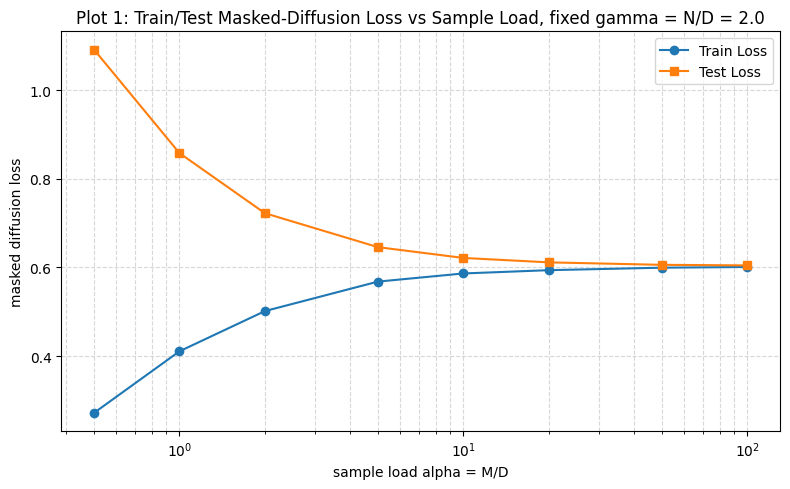

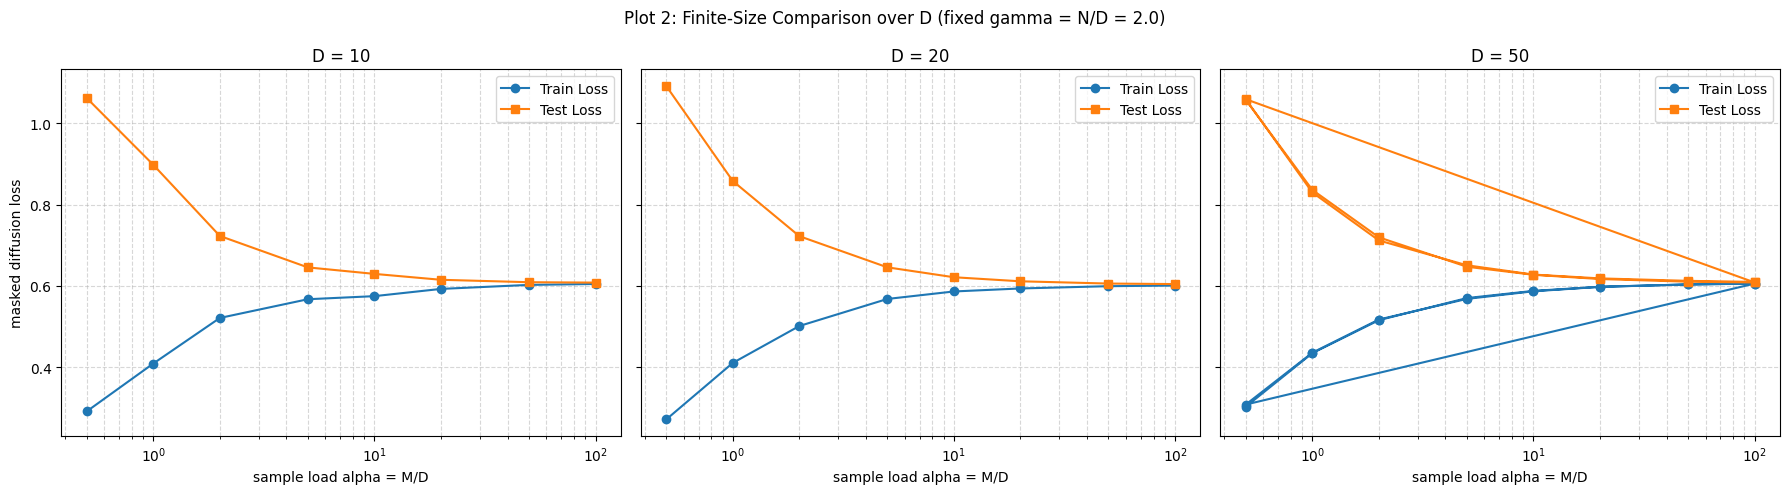

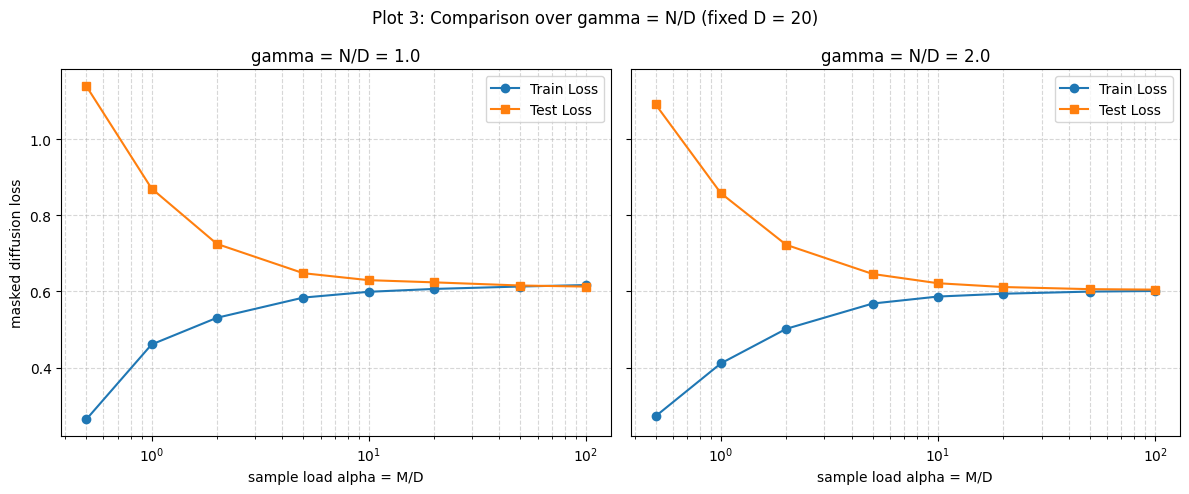

In [7]:
# Generate the three verification plots

# --- Plot 1: Main Convergence Plot (fixed D = 20, fixed gamma = 2.0) ---
df_plot1 = df[(df["D"] == 20) & (df["gamma"] == 2.0)]
if not df_plot1.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(df_plot1["alpha"], df_plot1["train_loss"], 'o-', label="Train Loss", color="#1f77b4")
    plt.plot(df_plot1["alpha"], df_plot1["test_loss"], 's-', label="Test Loss", color="#ff7f0e")
    plt.xscale("log")
    plt.xlabel("sample load alpha = M/D")
    plt.ylabel("masked diffusion loss")
    plt.title("Plot 1: Train/Test Masked-Diffusion Loss vs Sample Load, fixed gamma = N/D = 2.0")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("loss_convergence_plot1.png")
    plt.show()

# --- Plot 2: Finite-Size Comparison over D (fixed gamma = 2.0) ---
df_plot2 = df[df["gamma"] == 2.0]
unique_Ds = sorted(df_plot2["D"].unique())
if len(unique_Ds) > 0:
    fig, axes = plt.subplots(1, len(unique_Ds), figsize=(6 * len(unique_Ds), 5), sharey=True)
    if len(unique_Ds) == 1:
        axes = [axes]
    for i, D_val in enumerate(unique_Ds):
        ax = axes[i]
        sub_df = df_plot2[df_plot2["D"] == D_val]
        ax.plot(sub_df["alpha"], sub_df["train_loss"], 'o-', label="Train Loss", color="#1f77b4")
        ax.plot(sub_df["alpha"], sub_df["test_loss"], 's-', label="Test Loss", color="#ff7f0e")
        ax.set_xscale("log")
        ax.set_xlabel("sample load alpha = M/D")
        if i == 0:
            ax.set_ylabel("masked diffusion loss")
        ax.set_title(f"D = {D_val}")
        ax.legend()
        ax.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.suptitle("Plot 2: Finite-Size Comparison over D (fixed gamma = N/D = 2.0)")
    plt.tight_layout()
    plt.savefig("loss_convergence_plot2.png")
    plt.show()

# --- Plot 3: Comparison over gamma = N/D (fixed D = 20) ---
df_plot3 = df[df["D"] == 20]
unique_gammas = sorted(df_plot3["gamma"].unique())
if len(unique_gammas) > 0:
    fig, axes = plt.subplots(1, len(unique_gammas), figsize=(6 * len(unique_gammas), 5), sharey=True)
    if len(unique_gammas) == 1:
        axes = [axes]
    for i, gamma_val in enumerate(unique_gammas):
        ax = axes[i]
        sub_df = df_plot3[df_plot3["gamma"] == gamma_val]
        ax.plot(sub_df["alpha"], sub_df["train_loss"], 'o-', label="Train Loss", color="#1f77b4")
        ax.plot(sub_df["alpha"], sub_df["test_loss"], 's-', label="Test Loss", color="#ff7f0e")
        ax.set_xscale("log")
        ax.set_xlabel("sample load alpha = M/D")
        if i == 0:
            ax.set_ylabel("masked diffusion loss")
        ax.set_title(f"gamma = N/D = {gamma_val:.1f}")
        ax.legend()
        ax.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.suptitle("Plot 3: Comparison over gamma = N/D (fixed D = 20)")
    plt.tight_layout()
    plt.savefig("loss_convergence_plot3.png")
    plt.show()


## 11. Interpretation

The main x-axis is the professor’s sample load

$$
\alpha = M/D.
$$

For small $\alpha$, there are few samples per latent dimension. The model can fit finite-sample fluctuations, so the empirical training loss can be low while the test loss is high.

As $\alpha$ increases at fixed $\gamma=N/D$, the empirical distribution better approximates the distribution induced by the fixed random-feature matrix $F$. Therefore, the training loss is expected to increase toward the population value while the test loss decreases toward the same value.

When $D$ is varied, the comparison checks finite-size effects. If the statistical-physics scaling is appropriate, curves should become more stable as $D$ grows.

When $\gamma=N/D$ is varied, the comparison checks how the visible-to-latent aspect ratio affects the convergence.

Note that all statements refer to the expected qualitative behavior, rather than rigorous theorems.
